In [1]:
# Import library and Dataset
import pandas as pd

df=pd.read_csv("/content/day08_smartphone_resale_price_messy.csv")
df.head()

,phone_id,brand,model,age_months,original_price_inr,ram_gb,storage_gb,battery_health_percent,screen_size_inches,camera_mp,condition,warranty_months_left,repair_count,accessories_included,resale_price_inr
0,PH101357,OnePlus,iPhone 13,15.0,81453.0,NaN,512.0,70.0,6.5,108.0,Excellent,18.0,1.0,Yes,75385.0
1,PH100985,Google,OnePlus 11,13.0,15178.0,16.0,512.0,84.0,6.9,16.0,Good,13.0,1.0,Yes,34468.0
2,PH100860,Realme,Realme 11 Pro,58.0,97016.0,4.0,512.0,95.0,5.9,50.0,NaN,13.0,0.0,No,42808.0
3,PH101985,Oppo,OnePlus 11,48.0,95521.0,12.0,512.0,97.0,5.8,12.0,Good,1.0,2.0,Yes,46549.0
4,PH101294,Samsung,Vivo V29,18.0,31627.0,4.0,512.0,85.0,6.9,64.0,Good,6.0,1.0,No,31525.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   phone_id                2030 non-null   object 
 1   brand                   1995 non-null   object 
 2   model                   2030 non-null   object 
 3   age_months              1998 non-null   float64
 4   original_price_inr      1998 non-null   float64
 5   ram_gb                  2002 non-null   float64
 6   storage_gb              2030 non-null   float64
 7   battery_health_percent  1999 non-null   float64
 8   screen_size_inches      2030 non-null   float64
 9   camera_mp               2030 non-null   float64
 10  condition               2004 non-null   object 
 11  warranty_months_left    2003 non-null   float64
 12  repair_count            2030 non-null   float64
 13  accessories_included    2030 non-null   object 
 14  resale_price_inr        2030 non-null   

In [4]:
df.describe()

,age_months,original_price_inr,ram_gb,storage_gb,battery_health_percent,screen_size_inches,camera_mp,warranty_months_left,repair_count,resale_price_inr
count,1998.000000,1998.000000,2002.000000,2030.000000,1999.000000,2030.000000,2030.000000,2003.000000,2030.000000,2030.000000
mean,31.559059,80626.580080,9.197802,234.372414,79.821911,6.254729,66.672906,11.917624,1.492611,49003.767980
std,16.750556,40264.023406,4.330411,171.491101,11.636697,0.432416,57.366748,7.232523,1.123561,25355.615774
min,3.000000,12066.000000,4.000000,64.000000,60.000000,5.500000,12.000000,0.000000,0.000000,3000.000000
25%,17.000000,45735.500000,6.000000,64.000000,70.000000,5.900000,32.000000,6.000000,1.000000,29526.000000
50%,31.000000,81517.500000,8.000000,128.000000,80.000000,6.300000,50.000000,12.000000,1.000000,45474.000000
75%,46.000000,115753.250000,12.000000,256.000000,90.000000,6.600000,108.000000,18.000000,3.000000,64437.000000
max,60.000000,149941.000000,16.000000,512.000000,100.000000,7.000000,200.000000,24.000000,3.000000,139943.000000


In [8]:
df.columns.tolist()

['phone_id',
 'brand',
 'model',
 'age_months',
 'original_price_inr',
 'ram_gb',
 'storage_gb',
 'battery_health_percent',
 'screen_size_inches',
 'camera_mp',
 'condition',
 'warranty_months_left',
 'repair_count',
 'accessories_included',
 'resale_price_inr']

In [6]:
# check duplicated value
df.duplicated().sum()

np.int64(30)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(2000, 15)

In [19]:
# find the missing value
missing_values=df.isnull().sum()
print(missing_values)

phone_id                   0
brand                     35
model                      0
age_months                30
original_price_inr        32
ram_gb                    28
storage_gb                 0
battery_health_percent    31
screen_size_inches         0
camera_mp                  0
condition                 25
warranty_months_left      27
repair_count               0
accessories_included       0
resale_price_inr           0
dtype: int64


In [20]:
missing_values[missing_values>0]

,0
brand,35
age_months,30
original_price_inr,32
ram_gb,28
battery_health_percent,31
condition,25
warranty_months_left,27


In [21]:
missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage[missing_values>0].sort_values(ascending=False),

(brand                     1.75
 original_price_inr        1.60
 battery_health_percent    1.55
 age_months                1.50
 ram_gb                    1.40
 warranty_months_left      1.35
 condition                 1.25
 dtype: float64,)

In [22]:
df[
    [
        'age_months',
        'original_price_inr',
        'ram_gb',
        'battery_health_percent',
        'warranty_months_left'
    ]
].describe()

,age_months,original_price_inr,ram_gb,battery_health_percent,warranty_months_left
count,1970.000000,1968.000000,1972.000000,1969.000000,1973.000000
mean,31.646701,80686.790142,9.219067,79.841544,11.943740
std,16.726341,40267.844426,4.325972,11.623116,7.237872
min,3.000000,12066.000000,4.000000,60.000000,0.000000
25%,18.000000,45762.500000,6.000000,70.000000,6.000000
50%,31.000000,81711.000000,8.000000,80.000000,12.000000
75%,46.000000,115760.500000,12.000000,90.000000,18.000000
max,60.000000,149941.000000,16.000000,100.000000,24.000000


In [24]:
for col in ['brand','condition']:
  print("="*50)
  print(col)
  print(df[col].value_counts(dropna=False))

brand
brand
Samsung    264
Vivo       251
Xiaomi     245
Oppo       245
OnePlus    244
Realme     240
Google     239
Apple      237
NaN         35
Name: count, dtype: int64
condition
condition
Good         942
Excellent    462
Fair         454
Poor         117
NaN           25
Name: count, dtype: int64


In [28]:
# Seperate the numerical columns
numerical_columns=df.select_dtypes(include=['int64','float64']).columns.tolist()

for num_cols in numerical_columns:
  print(num_cols)

age_months
original_price_inr
ram_gb
storage_gb
battery_health_percent
screen_size_inches
camera_mp
warranty_months_left
repair_count
resale_price_inr


In [31]:
# Find the only numerical value missing
num_missing_cols=df[numerical_columns].columns[df[numerical_columns].isnull().any()].tolist()
for col in num_missing_cols:
  print(col)

age_months
original_price_inr
ram_gb
battery_health_percent
warranty_months_left


In [32]:
# fill the numerical value with median
for col in num_missing_cols:
  df[col]=df[col].fillna(df[col].median())

In [44]:
# remove the phone_id because it only identify not help to predict
df=df.drop(columns=['phone_id'])

In [46]:
# sepreate the categorical columns
categorical_columns=df.select_dtypes(include=['object']).columns.tolist()

for cat in categorical_columns:
  print(cat)

brand
model
condition
accessories_included


In [48]:
# find the missing value in categorical columns only
cat_missing_col=df[categorical_columns].columns[df[categorical_columns].isnull().any()].tolist()

for col in cat_missing_col:
  print(col)

In [49]:
# Fill the categorical columns with mode
for col in cat_missing_col:
  df[col]=df[col].fillna(df[col].mode()[0])

In [50]:
# verfiy the missing value
df.isnull().sum().sum()

np.int64(0)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2029
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand                   2000 non-null   object 
 1   model                   2000 non-null   object 
 2   age_months              2000 non-null   float64
 3   original_price_inr      2000 non-null   float64
 4   ram_gb                  2000 non-null   float64
 5   storage_gb              2000 non-null   float64
 6   battery_health_percent  2000 non-null   float64
 7   screen_size_inches      2000 non-null   float64
 8   camera_mp               2000 non-null   float64
 9   condition               2000 non-null   object 
 10  warranty_months_left    2000 non-null   float64
 11  repair_count            2000 non-null   float64
 12  accessories_included    2000 non-null   object 
 13  resale_price_inr        2000 non-null   float64
dtypes: float64(10), object(4)
memory usage: 234.4

In [52]:
# Explore the categorical columns
for col in categorical_columns:
  print("="*50)
  print("Columns :",col)
  print("Unique Values :",df[col].nunique())
  print(df[col].value_counts())

Columns : brand
Unique Values : 8
brand
Samsung    299
Vivo       251
Oppo       245
Xiaomi     245
OnePlus    244
Realme     240
Google     239
Apple      237
Name: count, dtype: int64
Columns : model
Unique Values : 8
model
Vivo V29         268
OnePlus 11       267
iPhone 13        260
Oppo Reno 10     256
Realme 11 Pro    243
Galaxy A54       243
Pixel 7          240
Redmi Note 13    223
Name: count, dtype: int64
Columns : condition
Unique Values : 4
condition
Good         967
Excellent    462
Fair         454
Poor         117
Name: count, dtype: int64
Columns : accessories_included
Unique Values : 2
accessories_included
Yes    1429
No      571
Name: count, dtype: int64


Categorical Features vs Target

In [53]:
# brand vs target
df.groupby('brand')['resale_price_inr'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
brand,,,
Apple,237,59149.725738,55140.0
OnePlus,244,52552.668033,48636.0
Google,239,52382.012552,48069.0
Samsung,299,49682.909699,46394.0
Vivo,251,45530.836653,42728.0
Xiaomi,245,45076.228571,41507.0
Oppo,245,44787.587755,41783.0
Realme,240,43183.616667,39279.0


In [55]:
# model vs target
df.groupby('model')['resale_price_inr'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
model,,,
OnePlus 11,267,50417.992509,48665.0
Oppo Reno 10,256,49835.140625,46344.0
iPhone 13,260,49713.696154,45158.5
Redmi Note 13,223,49118.201794,47348.0
Realme 11 Pro,243,48775.423868,46170.0
Vivo V29,268,48274.597015,44873.0
Pixel 7,240,48219.908333,44844.0
Galaxy A54,243,47587.045267,42248.0


In [58]:
# condition vs target
df.groupby('condition')['resale_price_inr'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
condition,,,
Excellent,462,53730.164502,50678.0
Good,967,50248.451913,45548.0
Fair,454,44741.852423,41899.5
Poor,117,36738.290598,35462.0


In [60]:
# accessories vs target
df.groupby('accessories_included')['resale_price_inr'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
accessories_included,,,
No,571,49434.595447,45887.0
Yes,1429,48843.678097,45192.0


Numerical Features vs Resale Price

In [61]:
correlation=df[numerical_columns].corr()['resale_price_inr'].sort_values(ascending=False)
print(correlation)

resale_price_inr          1.000000
original_price_inr        0.765654
storage_gb                0.189807
ram_gb                    0.082873
warranty_months_left      0.078347
battery_health_percent    0.033849
camera_mp                 0.004216
screen_size_inches       -0.023608
repair_count             -0.064645
age_months               -0.456958
Name: resale_price_inr, dtype: float64


Leakage Check

In [62]:
print(df.columns.tolist())

['brand', 'model', 'age_months', 'original_price_inr', 'ram_gb', 'storage_gb', 'battery_health_percent', 'screen_size_inches', 'camera_mp', 'condition', 'warranty_months_left', 'repair_count', 'accessories_included', 'resale_price_inr']


In [65]:
for col in df.columns:
  print("="*50)
  print("Column:",col)
  print("Unique values:",df[col].nunique())
  print(df[col].head())

Column: brand
Unique values: 8
0    OnePlus
1     Google
2     Realme
3       Oppo
4    Samsung
Name: brand, dtype: object
Column: model
Unique values: 8
0        iPhone 13
1       OnePlus 11
2    Realme 11 Pro
3       OnePlus 11
4         Vivo V29
Name: model, dtype: object
Column: age_months
Unique values: 58
0    15.0
1    13.0
2    58.0
3    48.0
4    18.0
Name: age_months, dtype: float64
Column: original_price_inr
Unique values: 1954
0    81453.0
1    15178.0
2    97016.0
3    95521.0
4    31627.0
Name: original_price_inr, dtype: float64
Column: ram_gb
Unique values: 5
0     8.0
1    16.0
2     4.0
3    12.0
4     4.0
Name: ram_gb, dtype: float64
Column: storage_gb
Unique values: 4
0    512.0
1    512.0
2    512.0
3    512.0
4    512.0
Name: storage_gb, dtype: float64
Column: battery_health_percent
Unique values: 41
0    70.0
1    84.0
2    95.0
3    97.0
4    85.0
Name: battery_health_percent, dtype: float64
Column: screen_size_inches
Unique values: 16
0    6.5
1    6.9
2    5.9


Create x and y

In [68]:
import numpy as np

x=df.drop(columns=['resale_price_inr'])
y=df['resale_price_inr']

numerical_features=x.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features=x.select_dtypes(
    include='object'
).columns.tolist()

print("x-shape :",x.shape)
print("y-shape :",y.shape)

print("\nNumerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

x-shape : (2000, 13)
y-shape : (2000,)

Numerical Features
['age_months', 'original_price_inr', 'ram_gb', 'storage_gb', 'battery_health_percent', 'screen_size_inches', 'camera_mp', 'warranty_months_left', 'repair_count']

Categorical Features
['brand', 'model', 'condition', 'accessories_included']


Train/Test Split

In [69]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("x-train :",x_train.shape)
print("x-test :",x_test.shape)


print("y-train :",y_train.shape)
print("y-test :",y_test.shape)


x-train : (1600, 13)
x-test : (400, 13)
y-train : (1600,)
y-test : (400,)


Build Preprocessing Pipeline

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# numerical preprocessing
numerical_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median'))
])

# categorical preprocessing
categorical_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# combine both
preprocessor=ColumnTransformer([
    ("num",numerical_pipeline,numerical_features),
    ('cat',categorical_pipeline,categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


Build the Baseline Random Forest Model

In [71]:
from sklearn.ensemble import RandomForestRegressor

In [72]:
# create a model
rf_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest Model created successfully")

Random Forest Model created successfully


Train the Baseline model

In [73]:
rf_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age_months',
                                                   'original_price_inr',
                                                   'ram_gb', 'storage_gb',
                                                   'battery_health_percent',
                                                   'screen_size_inches',
                                                   'camera_mp',
                                                   'warranty_months_left',
                                                   'repair_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['brand', 'model',
                                                   'condition',
                                                   'accessories_included'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [79]:
y_pred=rf_model.predict(x_test)

print("Predicted successfully.")

Predicted successfully.


Evaluate the model

In [80]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 Score :",r2)

MAE : 6165.140675
MSE : 67351920.28410825
RMSE : 8206.821570139578
R2 Score : 0.8862005746023597


Check for Overfitting

In [81]:
# Training predictions
y_train_pred = rf_model.predict(x_train)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print("Training Performance")
print("=" * 40)
print(f"MAE  : {train_mae:.2f}")
print(f"MSE  : {train_mse:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"R²   : {train_r2:.4f}")

print("\nTesting Performance")
print("=" * 40)
print(f"MAE  : {test_mae:.2f}")
print(f"MSE  : {test_mse:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 2242.96
MSE  : 9319481.73
RMSE : 3052.78
R²   : 0.9858

Testing Performance
MAE  : 6165.14
MSE  : 67351920.28
RMSE : 8206.82
R²   : 0.8862


Tune max_depth

In [82]:
depth_results = []

for depth in [5, 8, 10, 12, 15, 20, None]:

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    depth_results.append({
        'max_depth': depth,
        'Train_R2': r2_score(y_train, train_pred),
        'Test_R2': r2_score(y_test, test_pred),
        'Test_MAE': mean_absolute_error(y_test, test_pred),
        'Test_RMSE': np.sqrt(
            mean_squared_error(y_test, test_pred)
        )
    })

depth_results_df = pd.DataFrame(depth_results)

print(depth_results_df)

   max_depth  Train_R2   Test_R2     Test_MAE    Test_RMSE
0        5.0  0.890717  0.842050  7461.204389  9668.634192
1        8.0  0.962240  0.876085  6515.978685  8563.800060
2       10.0  0.979643  0.882948  6267.959109  8323.288878
3       12.0  0.984541  0.886208  6190.977582  8206.539415
4       15.0  0.985589  0.885071  6208.349739  8247.446314
5       20.0  0.985832  0.885866  6153.516647  8218.893341
6        NaN  0.985807  0.886201  6165.140675  8206.821570


Tune min_samples_split

In [83]:
split_results = []

for split in [2, 5, 10, 20, 30, 50]:

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_split=split,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    split_results.append({
        'min_samples_split': split,
        'Train_R2': r2_score(y_train, train_pred),
        'Test_R2': r2_score(y_test, test_pred),
        'Test_MAE': mean_absolute_error(y_test, test_pred),
        'Test_RMSE': np.sqrt(
            mean_squared_error(y_test, test_pred)
        )
    })

split_results_df = pd.DataFrame(split_results)

print(split_results_df)

   min_samples_split  Train_R2   Test_R2     Test_MAE    Test_RMSE
0                  2  0.984541  0.886208  6190.977582  8206.539415
1                  5  0.979606  0.884441  6225.503666  8270.017177
2                 10  0.966010  0.882012  6294.086725  8356.489039
3                 20  0.940495  0.871773  6599.453608  8711.534177
4                 30  0.921717  0.862191  6867.881885  9031.149084
5                 50  0.894569  0.846160  7282.313306  9541.996540


Tune min_samples_leaf

In [84]:
leaf_results = []

for leaf in [1, 2, 5, 10, 15, 20]:

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_split=2,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    leaf_results.append({
        'min_samples_leaf': leaf,
        'Train_R2': r2_score(y_train, train_pred),
        'Test_R2': r2_score(y_test, test_pred),
        'Test_MAE': mean_absolute_error(y_test, test_pred),
        'Test_RMSE': np.sqrt(
            mean_squared_error(y_test, test_pred)
        )
    })

leaf_results_df = pd.DataFrame(leaf_results)

print(leaf_results_df)

   min_samples_leaf  Train_R2   Test_R2     Test_MAE    Test_RMSE
0                 1  0.984541  0.886208  6190.977582  8206.539415
1                 2  0.978756  0.881885  6277.512371  8360.990595
2                 5  0.950159  0.873658  6492.951441  8647.282559
3                10  0.917727  0.858514  6889.125296  9150.866051
4                15  0.897923  0.843815  7232.106831  9614.465982
5                20  0.884123  0.834404  7487.910685  9899.881852


Tune n_estimators

In [85]:
n_estimators_results = []

for n in [50, 100, 150, 200, 300]:

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=n,
            max_depth=12,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    n_estimators_results.append({
        'n_estimators': n,
        'Train_R2': r2_score(y_train, train_pred),
        'Test_R2': r2_score(y_test, test_pred),
        'Test_MAE': mean_absolute_error(y_test, test_pred),
        'Test_RMSE': np.sqrt(
            mean_squared_error(y_test, test_pred)
        )
    })

n_estimators_results_df = pd.DataFrame(n_estimators_results)

print(n_estimators_results_df)

   n_estimators  Train_R2   Test_R2     Test_MAE    Test_RMSE
0            50  0.983613  0.882053  6259.624138  8355.050864
1           100  0.984541  0.886208  6190.977582  8206.539415
2           150  0.984861  0.886128  6179.285681  8209.427367
3           200  0.984788  0.885318  6188.086861  8238.569056
4           300  0.985122  0.886412  6157.135385  8199.206808


Final Random Forest configuration

In [86]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [87]:
final_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age_months',
                                                   'original_price_inr',
                                                   'ram_gb', 'storage_gb',
                                                   'battery_health_percent',
                                                   'screen_size_inches',
                                                   'camera_mp',
                                                   'warranty_months_left',
                                                   'repair_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['brand', 'model',
                                                   'condition',
                                                   'accessories_included'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [88]:
y_pred = final_model.predict(x_test)

In [90]:
comparison_df = pd.DataFrame({
    'Actual Price (Rs.)': y_test.values,
    'Predicted Price (Rs.)': y_pred
})

comparison_df['Error (Rs.)'] = (
    comparison_df['Actual Price (Rs.)']
    - comparison_df['Predicted Price (Rs.)']
)

comparison_df['Absolute Error (Rs.)'] = (
    comparison_df['Error (Rs.)'].abs()
)

comparison_df.head(10)

,Actual Price (Rs.),Predicted Price (Rs.),Error (Rs.),Absolute Error (Rs.)
0,33559.0,38025.948260,-4466.948260,4466.948260
1,64033.0,52216.671923,11816.328077,11816.328077
2,28614.0,35319.124599,-6705.124599,6705.124599
3,36215.0,38425.491045,-2210.491045,2210.491045
4,56297.0,59034.843513,-2737.843513,2737.843513
5,27781.0,25021.679763,2759.320237,2759.320237
6,43685.0,38728.085876,4956.914124,4956.914124
7,38694.0,41365.557130,-2671.557130,2671.557130
8,20766.0,31772.034784,-11006.034784,11006.034784
9,23147.0,25378.672144,-2231.672144,2231.672144


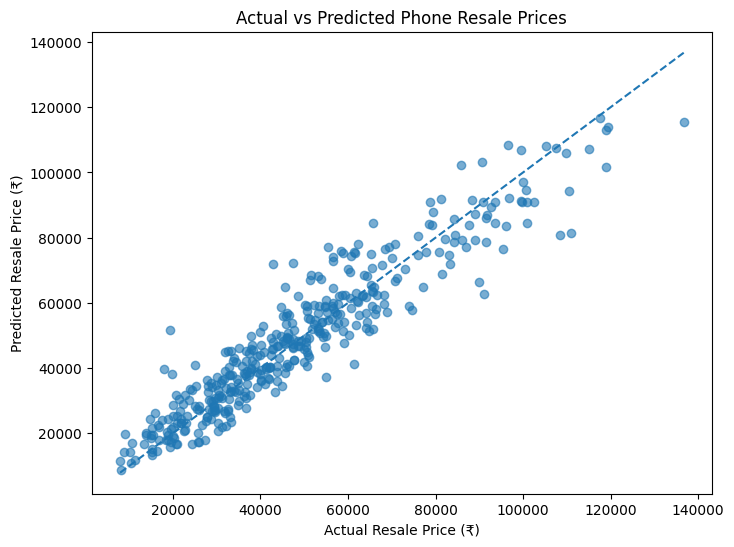

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Resale Price (₹)")
plt.ylabel("Predicted Resale Price (₹)")
plt.title("Actual vs Predicted Phone Resale Prices")

plt.show()

Calculate Residuals

In [92]:
residual_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_pred
})

residual_df['Residual'] = (
    residual_df['Actual_Price']
    - residual_df['Predicted_Price']
)

residual_df['Absolute_Error'] = residual_df['Residual'].abs()

residual_df.head(10)

,Actual_Price,Predicted_Price,Residual,Absolute_Error
0,33559.0,38025.948260,-4466.948260,4466.948260
1,64033.0,52216.671923,11816.328077,11816.328077
2,28614.0,35319.124599,-6705.124599,6705.124599
3,36215.0,38425.491045,-2210.491045,2210.491045
4,56297.0,59034.843513,-2737.843513,2737.843513
5,27781.0,25021.679763,2759.320237,2759.320237
6,43685.0,38728.085876,4956.914124,4956.914124
7,38694.0,41365.557130,-2671.557130,2671.557130
8,20766.0,31772.034784,-11006.034784,11006.034784
9,23147.0,25378.672144,-2231.672144,2231.672144


check residual statistics

In [93]:
print("Residual Statistics")
print("=" * 40)

print("Mean Residual :", residual_df['Residual'].mean())
print("Median Residual :", residual_df['Residual'].median())
print("Minimum Residual :", residual_df['Residual'].min())
print("Maximum Residual :", residual_df['Residual'].max())
print("Mean Absolute Error :", residual_df['Absolute_Error'].mean())

Residual Statistics
Mean Residual : -580.4962489035825
Median Residual : -478.3146302862124
Minimum Residual : -32333.85135579465
Maximum Residual : 29402.306259928242
Mean Absolute Error : 6157.135385075438


Residual Distribution

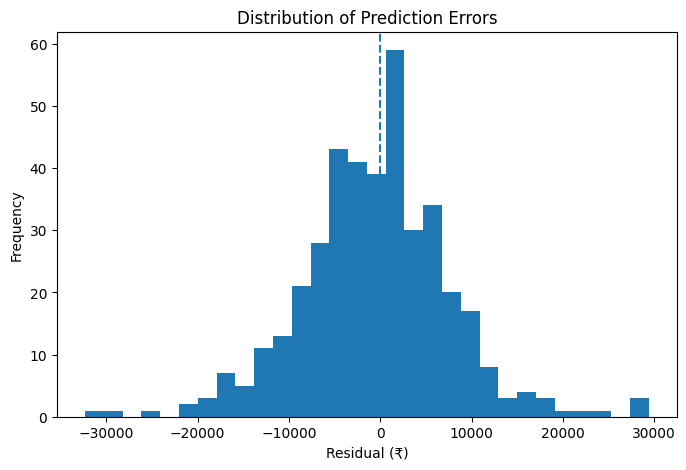

In [94]:
plt.figure(figsize=(8, 5))

plt.hist(
    residual_df['Residual'],
    bins=30
)

plt.axvline(
    0,
    linestyle='--'
)

plt.xlabel("Residual (₹)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

Residuals vs predicted price

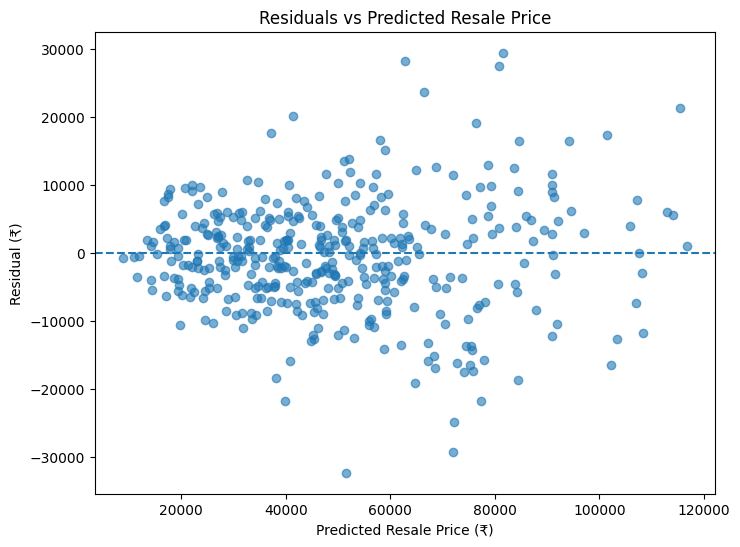

In [95]:
plt.figure(figsize=(8, 6))

plt.scatter(
    residual_df['Predicted_Price'],
    residual_df['Residual'],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel("Predicted Resale Price (₹)")
plt.ylabel("Residual (₹)")
plt.title("Residuals vs Predicted Resale Price")

plt.show()

Find the biggest prediction errors

In [96]:
largest_errors = (
    residual_df
    .sort_values('Absolute_Error', ascending=False)
    .head(10)
)

largest_errors

,Actual_Price,Predicted_Price,Residual,Absolute_Error
200,19224.0,51557.851356,-32333.851356,32333.851356
258,110935.0,81532.693740,29402.306260,29402.306260
192,42775.0,72009.022078,-29234.022078,29234.022078
124,90976.0,62742.126954,28233.873046,28233.873046
204,108363.0,80863.110772,27499.889228,27499.889228
386,47340.0,72169.714845,-24829.714845,24829.714845
217,89976.0,66369.353683,23606.646317,23606.646317
141,17982.0,39798.456050,-21816.456050,21816.456050
257,55535.0,77267.134774,-21732.134774,21732.134774
128,136712.0,115455.436122,21256.563878,21256.563878


Calcualte precentage error

In [97]:
residual_df['Percentage_Error'] = (
    residual_df['Absolute_Error']
    / residual_df['Actual_Price']
) * 100

print(
    "Mean Percentage Error :",
    residual_df['Percentage_Error'].mean()
)

Mean Percentage Error : 15.21120386306094


Create new phone and check the model

In [98]:
new_phones = pd.DataFrame({
    'brand': ['Apple', 'Samsung', 'Xiaomi', 'OnePlus', 'Google'],
    'model': ['iPhone 13', 'Galaxy A54', 'Redmi Note 13', 'OnePlus 11', 'Pixel 7'],
    'age_months': [12, 24, 36, 8, 18],
    'original_price_inr': [79999, 34999, 24999, 69999, 59999],
    'ram_gb': [6, 8, 8, 12, 8],
    'storage_gb': [128, 128, 256, 256, 128],
    'battery_health_percent': [92, 85, 76, 95, 88],
    'screen_size_inches': [6.1, 6.5, 6.6, 6.7, 6.3],
    'camera_mp': [12, 50, 108, 50, 50],
    'condition': ['Excellent', 'Good', 'Fair', 'Excellent', 'Good'],
    'warranty_months_left': [12, 6, 0, 18, 8],
    'repair_count': [0, 1, 3, 0, 1],
    'accessories_included': ['Yes', 'Yes', 'No', 'Yes', 'Yes']
})

new_phones

,brand,model,age_months,original_price_inr,ram_gb,storage_gb,battery_health_percent,screen_size_inches,camera_mp,condition,warranty_months_left,repair_count,accessories_included
0,Apple,iPhone 13,12,79999,6,128,92,6.1,12,Excellent,12,0,Yes
1,Samsung,Galaxy A54,24,34999,8,128,85,6.5,50,Good,6,1,Yes
2,Xiaomi,Redmi Note 13,36,24999,8,256,76,6.6,108,Fair,0,3,No
3,OnePlus,OnePlus 11,8,69999,12,256,95,6.7,50,Excellent,18,0,Yes
4,Google,Pixel 7,18,59999,8,128,88,6.3,50,Good,8,1,Yes


In [99]:
# predict resale prices
predicted_price=final_model.predict(new_phones)
new_phones["Predicted_Resale_Price_INR"]=predicted_price

new_phones[['brand','model','age_months','condition','Predicted_Resale_Price_INR']]

,brand,model,age_months,condition,Predicted_Resale_Price_INR
0,Apple,iPhone 13,12,Excellent,65655.921133
1,Samsung,Galaxy A54,24,Good,24415.399215
2,Xiaomi,Redmi Note 13,36,Fair,19436.521073
3,OnePlus,OnePlus 11,8,Excellent,64320.769319
4,Google,Pixel 7,18,Good,44828.892574


In [100]:
result = new_phones.copy()

result['Predicted_Resale_Price_INR'] = (
    result['Predicted_Resale_Price_INR']
    .round(2)
)

result[['brand', 'model',
        'age_months',
        'condition',
        'Predicted_Resale_Price_INR']]

,brand,model,age_months,condition,Predicted_Resale_Price_INR
0,Apple,iPhone 13,12,Excellent,65655.92
1,Samsung,Galaxy A54,24,Good,24415.40
2,Xiaomi,Redmi Note 13,36,Fair,19436.52
3,OnePlus,OnePlus 11,8,Excellent,64320.77
4,Google,Pixel 7,18,Good,44828.89


In [101]:
import joblib

joblib.dump(final_model,"DAY 08 — SMARTPHONE RESALE PRICE PREDICTION.pkl")

['DAY 08 — SMARTPHONE RESALE PRICE PREDICTION.pkl']